In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.0 MB/s eta 0:00:34
    --------------------------------------- 1.3/69.5 MB 2.1 MB/s eta 0:00:33
    --------------------------------------- 1.6/69.5 MB 2.0 MB/s eta 0:00:35
    --------------------------------------- 1.6/69.5 MB 2.0 MB/s eta 0:00:35
   - -------------------------------------- 2.4/69.5 MB 1.9 MB/s eta 0:00:37
   - -------------------------------------- 2.4/69.5 MB 1.9 MB/s eta 0:00:37
   - -------------------------------------- 2.9/69.5 MB 1.8 MB/s eta 0:00:38
   - -------------------------------------- 2.9/69.5 MB 1.8 MB/s eta 0:00:38
   - -------------------------------------- 3.1/69.5 MB 1.5 MB/s eta 0:00:44
   - -------------------------------------- 3.4/69.5 MB 1.5 MB/s eta 0:00:45
   -- --------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("../data/processed/model_ready_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

print(df.shape)
df.head()

(3936, 45)


,Date,NVDA_Open,NVDA_High,NVDA_Low,NVDA_Close,NVDA_Volume,SP500_Open,SP500_High,SP500_Low,SP500_Close,...,NVDA_EMA_12,NVDA_EMA_26,NVDA_MACD,NVDA_MACD_Signal,NVDA_Volatility_7,NVDA_Volatility_30,NVDA_Close_Lag_1,NVDA_Close_Lag_7,NVDA_Close_Lag_30,Target_Next_Close
0,2010-05-12,0.331948,0.337900,0.329887,0.336068,9.012360e+08,1155.430054,1172.869995,1155.430054,1171.670044,...,0.344567,0.361494,-0.016927,-0.013719,0.030320,0.023612,0.329658,0.355756,0.403602,0.335382
1,2010-05-13,0.334695,0.350033,0.332177,0.335382,1.252000e+09,1170.040039,1173.569946,1156.140015,1157.439941,...,0.343154,0.359560,-0.016406,-0.014256,0.023620,0.023581,0.336068,0.337671,0.398337,0.296693
2,2010-05-14,0.312718,0.313633,0.288451,0.296693,2.493068e+09,1157.189941,1157.189941,1126.140015,1135.680054,...,0.336006,0.354903,-0.018897,-0.015184,0.049732,0.030970,0.335382,0.331948,0.394216,0.297379
3,2010-05-17,0.297150,0.301042,0.287993,0.297379,8.560600e+08,1136.520020,1141.880005,1114.959961,1136.939941,...,0.330063,0.350642,-0.020579,-0.016263,0.050036,0.030715,0.296693,0.325080,0.400169,0.287535
4,2010-05-18,0.299897,0.301729,0.285933,0.287535,6.741120e+08,1138.780029,1148.660034,1117.199951,1120.800049,...,0.323520,0.345967,-0.022447,-0.017500,0.050698,0.030899,0.297379,0.319586,0.390325,0.292114


In [4]:
target = "Target_Next_Close"

X = df.drop(columns=["Date", target])
y = df[target]

# Remove columns with all missing values
X = X.dropna(axis=1, how="all")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3936, 43)
y shape: (3936,)


In [5]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = df["Date"].iloc[split_index:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3148, 43)
Test: (788, 43)


In [6]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [7]:
y_pred = xgb_model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("XGBoost Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

XGBoost Results
MAE: 67.77945336158162
RMSE: 86.23167238475949
R2 Score: -1.436187565349282


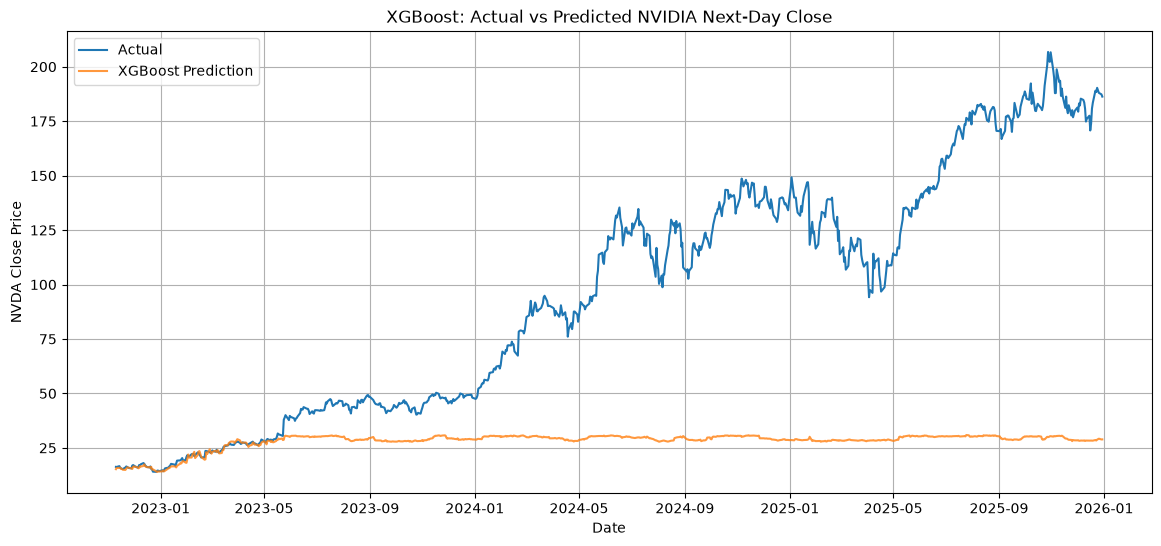

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test, label="Actual")
plt.plot(dates_test, y_pred, label="XGBoost Prediction", alpha=0.8)

plt.title("XGBoost: Actual vs Predicted NVIDIA Next-Day Close")
plt.xlabel("Date")
plt.ylabel("NVDA Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
df = pd.read_csv("../data/processed/model_ready_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df["Target_Next_Return"] = df["NVDA_Close"].pct_change().shift(-1)
df = df.dropna()

target = "Target_Next_Return"

X = df.drop(columns=["Date", "Target_Next_Close", target])
y = df[target]

X = X.dropna(axis=1, how="all")

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

dates_test = df["Date"].iloc[split_index:]
today_close_test = df["NVDA_Close"].iloc[split_index:]

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

pred_return = xgb_model.predict(X_test)

pred_next_close = today_close_test.values * (1 + pred_return)
actual_next_close = df["Target_Next_Close"].iloc[split_index:].values

In [11]:
mae = mean_absolute_error(actual_next_close, pred_next_close)
rmse = np.sqrt(mean_squared_error(actual_next_close, pred_next_close))
r2 = r2_score(actual_next_close, pred_next_close)

print("XGBoost Return-Based Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

XGBoost Return-Based Results
MAE: 2.3642503294031556
RMSE: 3.554273038866422
R2 Score: 0.9958522914504854


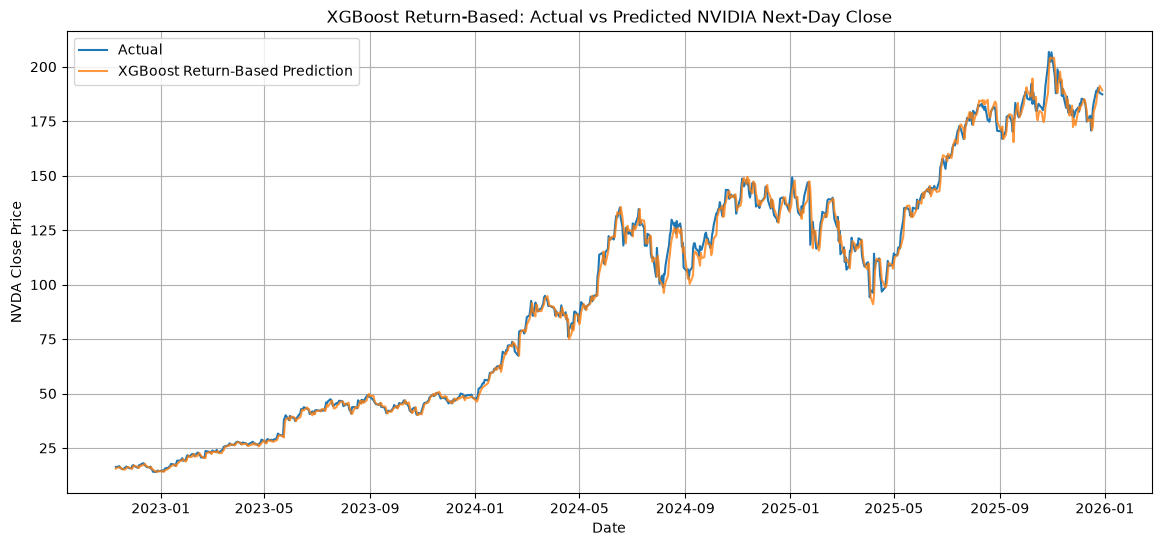

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(dates_test, actual_next_close, label="Actual")
plt.plot(dates_test, pred_next_close, label="XGBoost Return-Based Prediction", alpha=0.8)

plt.title("XGBoost Return-Based: Actual vs Predicted NVIDIA Next-Day Close")
plt.xlabel("Date")
plt.ylabel("NVDA Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(20))

              Feature  Importance
31         NVDA_SMA_7    0.032297
34        NVDA_EMA_12    0.031422
25           VIX_Open    0.030260
30        NVDA_Return    0.030195
26           VIX_High    0.029645
27            VIX_Low    0.029474
35        NVDA_EMA_26    0.029332
28          VIX_Close    0.029227
42  NVDA_Close_Lag_30    0.028907
33        NVDA_SMA_90    0.028619
22    Treasury10Y_Low    0.026814
7           SP500_Low    0.026195
8         SP500_Close    0.025564
16           Oil_High    0.024654
19         Oil_Volume    0.024614
17            Oil_Low    0.024475
6          SP500_High    0.024475
32        NVDA_SMA_30    0.024396
1           NVDA_High    0.024309
13         Gold_Close    0.024186


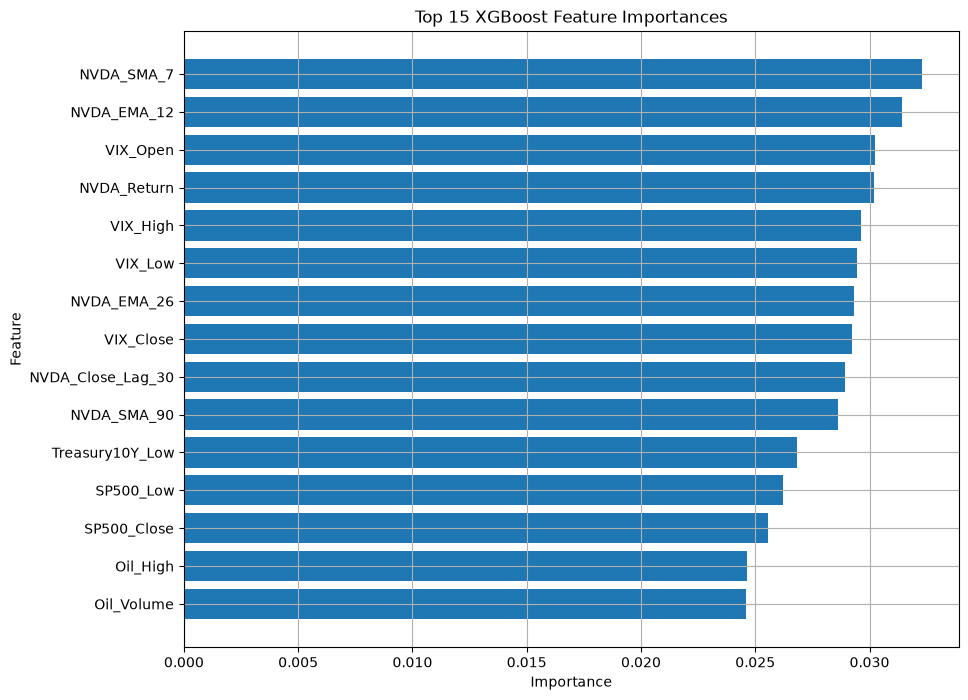

In [14]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"].head(15)[::-1],
    feature_importance["Importance"].head(15)[::-1]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

In [15]:
feature_importance.to_csv(
    "../data/processed/xgboost_feature_importance.csv",
    index=False
)

In [16]:
model_comparison = pd.DataFrame({
    "Model": [
        "Walk-Forward ARIMA",
        "Walk-Forward SARIMAX",
        "XGBoost Return-Based"
    ],
    "MAE": [
        2.09,
        1.81,
        2.36
    ],
    "RMSE": [
        3.18,
        2.77,
        3.55
    ],
    "R2 Score": [
        0.9967,
        0.9975,
        0.9959
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Walk-Forward ARIMA,2.09,3.18,0.9967
1,Walk-Forward SARIMAX,1.81,2.77,0.9975
2,XGBoost Return-Based,2.36,3.55,0.9959
